In [3]:
from Plotting_base_code import plotting_pytorch as plotting
from CNN_code import cnn_create
import os
import pandas as pd
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import ast
import numpy as np
plt.style.use('tableau-colorblind10')
from matplotlib.lines import Line2D

colors_blind=['#006BA4', '#FF800E', '#ABABAB', '#595959',
                 '#5F9ED1', '#C85200', '#898989', '#A2C8EC', '#FFBC79', '#CFCFCF']

/home/simrank/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [4]:
class plot:
    def __init__(self):
        self.x_fontsize_label=25
        self.y_fontsize_label=25
        self.x_fontsize=15
        self.y_fontsize=15
        self.t_fontsize=20
        self.size_prop=15

        self.row=7
        self.col=5


        self.figure_size=(20,25)
        # figure_size=(10,12)
        self.rotation=30
        self.w_space=0.1
        self.h_space=0.1
        self.markersize=5
        self.title_font=15
        self.label_text='% corruption degree'
        self.x_label='Epoch'
        self.pad_value=10
        self.corruption=[0.0,0.2,0.4,0.6,0.8,1.0]
        
 
    def divide_function(self,list_value,int_value):
        newList = []
        for x in list_value:
            newList.append(x/int_value)
        return newList
    def print_x_axis(self,values_xaxis):
        x_labels = list(map(int, values_xaxis))  
        max_val = max(x_labels)

        # Decide step size adaptively
        if max_val <= 40:
            tick_labels = list(range(0, max_val + 1, 10))
        else:
            tick_labels = list(range(0, max_val + 1, 40))

        # Find closest indices in x_labels for each desired tick
        tick_indices = [min(range(len(x_labels)), key=lambda i: abs(x_labels[i] - val))
                        for val in tick_labels if val <= max_val]

        return tick_labels, tick_indices, x_labels

    
        
    def accuracy_model(self,type_acc,data_name,corrupt,tiny=False):
        if data_name=='Corrupted Training':
            data='Train_accuracy'
    #     if data_name=='Original Training':
    #         data='Train_accuracy_original'
        if data_name=='Testing':
            data='Test_accuracy'
        run=[]
        for run_type in range(1,4,1):
            if tiny:
                num_epoch,min_epoch=plotting.final_epoch_tiny(corrupt,run_type)
                x_acc=[i for i in range(-1,min_epoch,1)]+[num_epoch]
                x_acc[0]=0
                if corrupt==0.8 or corrupt==1.0:
                    models_load=cnn_create.select_model(x_acc,tiny)
                else:
                    models_load=cnn_create.select_model(x_acc,tiny)+[x_acc[-1]-1]        
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                           .sort_values(by='epoch')[data]
                                           [models_load].tolist(),100))
            else:
                
                num_epoch=(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                           .sort_values(by='epoch')['epoch']).tolist()[-1]
                x_acc=[i for i in range(-1,num_epoch,1)]
                x_acc[0]=0
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                           .sort_values(by='epoch')[data]
                                           [cnn_create.select_model(x_acc,tiny)].tolist(),100))
   
        return run
    
    def label_names_fn(self,network,data_name):
        if data_name=='Testing':
            name_title='Test'
        if data_name=='Corrupted Training':
            name_title='data_name'
        if network =='MLP':
            labels_names=[f'Model {name_title} Accuracy','Input','FC1 (128)',
                      'FC2 (512)','FC3 (2048)','FC4 (2048)']        

        if network =='CNN': 
            labels_names=[f'Model {name_title} Accuracy','Input','Flat (576/1024)',
                          'FC1 (250)','FC2 (250)','FC3 (250)'] 
            
        if network =='AlexNet':
            labels_names= [f'Model {name_title} Accuracy','Flat (256)','FC1 (4096)','FC2 (4096)']  
        if network =='ResNet18':
            labels_names= [f'Model {name_title} Accuracy','L0','L1','L2','L3','L4','Avg_pool']  #
        return labels_names
    
    def layer_info(self,network):
        if network =='MLP':
            labels_names=[f'Model test accuracy','Input',
                          'FC1 (128)','FC2 (512)','FC3 (2048)','FC4 (2048)']        
            data_layer_name=['input','fc1','fc2','fc3','fc4']                

        elif network =='CNN': 
            labels_names=[f'Model test accuracy','Input',
                      'Flat (576/1024)',
                      'FC1 (250)','FC2 (250)','FC3 (250)']        

            data_layer_name=['input','flattern','fc1','fc2','fc3']
        elif network =='AlexNet':     
            labels_names=[f'Model test accuracy','Flat (256)',
                          'FC1 (4096)','FC2 (4096)']        
            data_layer_name=['flattern','fc1','fc2']

        elif network =='ResNet18':       
            labels_names = ['Model test accuracy','L0','L1',
                            'L2','L3','L4','Avg_pool'] #
            data_layer_name = ['l0','l1','l2','l3','l4','bf_last']#
        return labels_names,data_layer_name

        
    def folder_results(self,resfoldername, fold_type):
        
        os.makedirs(f'{resfoldername}',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}/pdf',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}/png',exist_ok=True)

        result1=f'{resfoldername}/{fold_type}/pdf'
        result2=f'{resfoldername}/{fold_type}/png'
        
        return [result1 , result2]
    
   
    
    def accuracy_model_all(self,type_acc,data_name,corrupt,tiny=False):
        run=[]
        if data_name=='Corrupted Training':
            data='Train_accuracy'

        if data_name=='Testing':
            data='Test_accuracy'

        for run_type in ['Run_1','Run_2','Run_3']:

            num_epoch=(pd.read_csv(f'{type_acc}/{run_type}.csv')
                       .sort_values(by='epoch')['epoch']).tolist()[-1]
            x_acc=[i for i in range(-1,num_epoch,1)]
            x_acc[0]=0

            if data_name=='Original Training':
                if corrupt ==0.0:
                    data='Train_accuracy'
                    run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))
                else:
                    data='Train_accuracy_org'
                    run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}_org.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))

            else:
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))

        return run
    
    def main_appendix(self,subspace_type,data_name,n):
        networks=['MLP','MLP','CNN','CNN','CNN']
        data_types=['MNIST','CIFAR10','MNIST','CIFAR10','FashionMNIST']
        labels_names_total=[f'Model test accuracy','Input/ ResNet-18-L0',
                    'MLP-FC1 (128)/ CNN-Flat (576/1024)/ AlexNet-Flat (256)/ ResNet-18-L1',
                    'MLP-FC2 (512)/ CNN-FC1 (250)/ AlexNet-FC1 (4096)/ ResNet-18-L2',
                    'MLP-FC3 (2048)/ CNN-FC2 (250)/ AlexNet-FC2 (4096)/ ResNet-18-L3',
                    'MLP-FC4 (2048)/ CNN-FC3 (250)/ ResNet-18-L4','ResNet-18-Avg_pool']  

        file_final_name=f'ACCURACY_{subspace_type}_{data_name}_{n}_all'

        return networks,data_types,labels_names_total,file_final_name
    def fun_1(self,train_overall,classnumber=99):
        if classnumber==99:
            max_value = list(map(max, zip(train_overall[0], train_overall[1],train_overall[2])))
            min_value = list(map(min, zip(train_overall[0], train_overall[1],train_overall[2])))
            avg_value = list(map(sum, zip(train_overall[0], train_overall[1],train_overall[2])))
            avg_value = [x/3 for x in avg_value]
        else:
            max_value = list(map(max, zip(train_overall[0][classnumber], train_overall[1][classnumber],train_overall[2][classnumber])))
            min_value = list(map(min, zip(train_overall[0][classnumber], train_overall[1][classnumber],train_overall[2][classnumber])))
            avg_value = list(map(sum, zip(train_overall[0][classnumber], train_overall[1][classnumber],train_overall[2][classnumber])))
            avg_value = [x/3 for x in avg_value]
        return max_value,min_value,avg_value

    def path(self,network,data_type,corrupt,n):    
        if n==0.99:
            typex=f'../pca_during_training_angle/angle_results/{data_type}_{network}/results_{corrupt}'
            type_acc=f'../pca_during_training_angle/angle_results/{data_type}_{network}/Accuracy_results/{corrupt}'
        if n==1:
            typex=f'../pca_during_training_angle/angle_results_1pc/{data_type}_{network}/results_{corrupt}'
            type_acc=f'../pca_during_training_angle/angle_results/{data_type}_{network}/Accuracy_results/{corrupt}'
        if network=='ResNet18':
            typex=f'../TMLR_ResNet18_during_training/results/40/angle_results_{n}/{data_type}_{network}/results_{corrupt}'
            type_acc=f'../TMLR_compare/Modern_backbones/models/{data_type}_{network}/Accuracy_results/{corrupt}'
        return typex,type_acc
    def accuracy_model_tiny(self,type_acc,data_name,path_x_values,corrupt,tiny=False):

        run=[]
        if data_name=='Corrupted Training':
            data='Train_accuracy'
        if data_name=='Testing':
            data='Test_accuracy'


        len_x_run=[]
        last_values_xaxis=[]

        for run_type in range(1,4):  
            num_epoch,min_epoch=plotting.final_epoch_tiny(corrupt,run_type)
            x_acc=[i for i in range(-1,min_epoch,1)]+[num_epoch]
            x_acc[0]=0
            if corrupt==0.8 or corrupt==1.0:
                models_load=cnn_create.select_model(x_acc,tiny)
            else:
                models_load=cnn_create.select_model(x_acc,tiny)+[x_acc[-1]-1]        
            run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                       .sort_values(by='epoch')[data]
                                       [models_load].tolist(),100))

            path_model_num=f'{path_x_values}/angle_results/Run_{run_type}/'
            len_x_run.append(len(os.listdir(path_model_num)))
            if tiny:
                last_values_xaxis.append(sorted(os.listdir(path_model_num),key=int)[-1])
        len_x=min(len_x_run)
        x=[i for i in range(len_x)]
        ind_len=len_x_run.index(len_x)                     
        path_model=f'{path_x_values}/angle_results/Run_{ind_len+1}/'      
        if tiny:
            values_xaxis=sorted(os.listdir(path_model),key=int)[:-1]
            values_xaxis=values_xaxis+last_values_xaxis
        else:
            values_xaxis=sorted(os.listdir(path_model),key=int)

        return run,values_xaxis,x
    
    
    def read_file_name(self,data_name,type_cnn,folder_name,run,model_number,layer):
        if data_name == 'Testing' :
            file_name=f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv'
        if data_name == 'Corrupted Training' :
            file_name=f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_train.csv'
        if data_name == 'Original Training' :
            file_name=f'{type_cnn}/angle_results_exp2/Run_{run}/{model_number}/layer_{layer}_acc_overall_train.csv'
        return file_name
    def mavc_velpic_acc(self,network,data_type,corrupt,train,data_name):
        folder_name='angle_results'

        data_layer_name=plotting.layer_name_acc(network)
        labels_names=self.label_names_fn(network,data_name)    
        avg_value_velpic=[]
        avg_value_masc=[]
        for layer,labels_name in zip(data_layer_name,labels_names[1:]):
            mavc=False
            n=0.99
            type_cnn,_=plotting.path(network,data_type,corrupt,n,mavc,train)
#             print(type_cnn)
            run_layer=[]
            values_xaxis,_=plotting.epoch_all_accuracy(type_cnn)
            for run in range(1,4):
                run_value=[]
                for model_number in values_xaxis:
                    run_value.append(pd.read_csv(f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0])

                run_layer.append(run_value)
            _,_,avg_value=plotting.fun_1(run_layer)
            avg_value_masc.append(avg_value)

            #                 ----------------------

            mavc=True
            n=1
            type_cnn,_=plotting.path(network,data_type,corrupt,n,mavc,train)
#             print(type_cnn)
            run_layer_velpic=[]
            for run in range(1,4):
                run_value=[]
                for model_number in values_xaxis:
                    run_value.append(pd.read_csv(f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0])
                run_layer_velpic.append(run_value)
            _,_,avg_value=plotting.fun_1(run_layer_velpic)
            avg_value_velpic.append(avg_value)
        return avg_value_masc,avg_value_velpic

    def mavc_velpic_acc_alexnet(self,network,data_type,corrupt,train,values_xaxis,data_name):
        folder_name='angle_results'

        labels_names,data_layer_name=self.layer_info(network)
        #                 ----------------------
        avg_value_velpic=[]
        avg_value_masc=[]
        for layer,labels_name in zip(data_layer_name,labels_names[1:]):
            mavc=False
            n=0.99
            type_cnn,_=plotting.path(network,data_type,corrupt,n,mavc,train)
#             print(type_cnn)

            run_layer=[]
            for run in range(1,4):
                run_value=[]
                for model_number in values_xaxis[:-3]:
                    file_name_final=self.read_file_name(data_name,type_cnn,
                                                           folder_name,run,
                                                           model_number,layer)
                    run_value.append(pd.read_csv(file_name_final)['acc_overall'][0])

                model_number= values_xaxis[-4+run]
                file_name_final=self.read_file_name(data_name,type_cnn,
                                                           folder_name,run,
                                                           model_number,layer)
                run_value.append(pd.read_csv(file_name_final)['acc_overall'][0])

                run_layer.append(run_value)
            _,_,avg_value=plotting.fun_1(run_layer)
            avg_value_masc.append(avg_value)
    #                 ----------------------                    
            mavc=True
            n=1
            type_cnn,_=plotting.path(network,data_type,corrupt,n,mavc,train)
#             print(type_cnn)
            run_layer_velpic=[]
            for run in range(1,4):
                run_value=[]
                for model_number in values_xaxis[:-3]:
                    file_name_final=self.read_file_name(data_name,type_cnn,
                                                           folder_name,run,
                                                           model_number,layer)
                    run_value.append(pd.read_csv(file_name_final)['acc_overall'][0])

                model_number= values_xaxis[-4+run]
                file_name_final=self.read_file_name(data_name,type_cnn,
                                                           folder_name,run,
                                                           model_number,layer)
                run_value.append(pd.read_csv(file_name_final)['acc_overall'][0])

                run_layer_velpic.append(run_value)
            _,_,avg_value=plotting.fun_1(run_layer_velpic)
            avg_value_velpic.append(avg_value)
    #                 ----------------------
        
        
        return avg_value_masc,avg_value_velpic
    def max_over_layers(self,avg_v,epochnum):
        epoch_values=[]
        for layers in range(len(avg_v)):
            epoch_values.append(avg_v[layers][epochnum])

        return max(epoch_values)
    def bar_models_random(self,resfoldername):  
        train=True
        data_name='Testing'
        name_title='Test'

        subspace_type='corrupt'
        folder_name='angle_results'

        fold_type='ACCURACY'
        result1,result2=self.folder_results(resfoldername,fold_type)

        self.corruption=[0.0,0.2,0.4,0.6,0.8]
        name_2='0_8'
        self.figure_size=(20,20)
        self.col=3
        self.row=2
        n=1
        networks,data_types,labels_names_total,file_final_name=self.main_appendix(subspace_type,data_name,n)


        labels={'label1':'Random Initialized Model',
                'label2':'Trained Model ',
                'label3':'MASC on Initialized Model',
                'label4':'MASC on Trained Model',
                'label5':'VeLPIC on Initialized Model',
                'label6':'VeLPIC on Trained Model'
               }

        figure_size=(15,12)

        fig = plt.figure(figsize=figure_size)
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=None)
        x_label='Models-dataset'
        y_label='Test Accuracy'
        x_fontsize_label=15
        y_fontsize_label=15

        count=1
        barWidth = 0.15
        num_model=7
        size_prop=10
        br1 = np.arange(num_model) 
        br2 = [x + barWidth for x in br1] 
        br3 = [x + barWidth for x in br2] 
        br4 = [x + barWidth for x in br3] 
        br5 = [x + barWidth for x in br4] 
        br6 = [x + barWidth for x in br5] 
        epoch1=0
        epoch2=-1
        mavc=True
        for corrupt in self.corruption:
            print(corrupt)
            fig.add_subplot(self.row, self.col,count)

            model_test_random=[]
            model_test_trained=[]
            masc_test_random=[]
            masc_test_trained=[]
            velpic_test_random=[]
            velpic_test_trained=[]
            for network,data_type in zip(networks,data_types):


                _,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)
#                 print(type_acc)

                run_acc=self.accuracy_model(type_acc,data_name,corrupt)


                max_value,min_value,avg_value=self.fun_1(run_acc)

                max_value[0]=0.10
                min_value[0]=0.10
                avg_value[0]=0.10
                model_test_random.append(avg_value[epoch1])
                model_test_trained.append(avg_value[epoch2])
#                 print("model",model_test_random)

                avg_value_masc,avg_value_velpic=self.mavc_velpic_acc(network,data_type,corrupt,train,data_name)

                masc_test_random.append(self.max_over_layers(avg_value_masc,epoch1))
                masc_test_trained.append(self.max_over_layers(avg_value_masc,epoch2))
#                 print("masc",masc_test_random)

                velpic_test_random.append(self.max_over_layers(avg_value_velpic,epoch1))
                velpic_test_trained.append(self.max_over_layers(avg_value_velpic,epoch2))



            network='AlexNet'
            data_type='TinyImageNet'  

            labels_names,data_layer_name=self.layer_info(network)
            type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)

            run_acc,values_xaxis,x=self.accuracy_model_tiny(type_acc,data_name,
                                                  type_cnn,corrupt,tiny=True)

            max_value,min_value,avg_value=plotting.fun_1(run_acc)

            max_value[0]=0.005
            min_value[0]=0.005
            avg_value[0]=0.005



            model_test_random.append(avg_value[epoch1])
            model_test_trained.append(avg_value[epoch2])


            avg_value_masc,avg_value_velpic=self.mavc_velpic_acc_alexnet(network,data_type,corrupt,train,
                                                                      values_xaxis,data_name)

            masc_test_random.append(self.max_over_layers(avg_value_masc,epoch1))
            masc_test_trained.append(self.max_over_layers(avg_value_masc,epoch2))

            velpic_test_random.append(self.max_over_layers(avg_value_velpic,epoch1))
            velpic_test_trained.append(self.max_over_layers(avg_value_velpic,epoch2))


            network='ResNet18'
            data_type='CIFAR10' 

            data_layer_name=plotting.layer_name_acc(network)


            _,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)
#             print(type_acc)


            run_acc=self.accuracy_model(type_acc,data_name,corrupt)
            values_xaxis,x=plotting.epoch_all_accuracy(type_cnn)

            max_value,min_value,avg_value=plotting.fun_1(run_acc)

            max_value[0]=0.10
            min_value[0]=0.10
            avg_value[0]=0.10
            model_test_random.append(avg_value[epoch1])
            model_test_trained.append(avg_value[epoch2])

            avg_value_masc,avg_value_velpic=self.mavc_velpic_acc(network,data_type,corrupt,train,data_name)

            masc_test_random.append(self.max_over_layers(avg_value_masc,epoch1))
            masc_test_trained.append(self.max_over_layers(avg_value_masc,epoch2))

            velpic_test_random.append(self.max_over_layers(avg_value_velpic,epoch1))
            velpic_test_trained.append(self.max_over_layers(avg_value_velpic,epoch2))


            plt.bar(br1,model_test_random,alpha=0.5, width = barWidth,label=labels['label1']
                    ,edgecolor ='grey', color=colors_blind[4])
            plt.bar(br2,model_test_trained,alpha=0.5,width = barWidth, label=labels['label2']
                    ,edgecolor ='grey', color=colors_blind[0])
            plt.bar(br3,masc_test_random,alpha=0.5,width = barWidth, label=labels['label3']
                    ,edgecolor ='grey', color=colors_blind[2])
            plt.bar(br4,masc_test_trained,alpha=0.5,width = barWidth, label=labels['label4']
                    ,edgecolor ='grey', color=colors_blind[3])
            plt.bar(br5,velpic_test_random,alpha=0.5,width = barWidth, label=labels['label5']
                    ,edgecolor ='grey', color=colors_blind[1])
            plt.bar(br6,velpic_test_trained,alpha=0.5,width = barWidth, label=labels['label6']
                    ,edgecolor ='grey', color=colors_blind[5])


            plt.xticks([r + barWidth for r in range(num_model)], 
                ['MLP-MNIST','MLP-CIFAR-10','CNN-MNIST','CNN-CIFAR-10','CNN-Fashion-MNIST', 'AlexNet-Tiny ImageNet',
                 'ResNet-18-CIFAR-10'],
                   rotation=20)


            plt.title(f'{plotting.get_corrupt(corrupt)}% corruption degree')
            plt.ylim(0,1)
            if (count - 1) % self.col != 0:  
                plt.tick_params(labelleft=False)
            if count< (self.col*self.row)-self.col:
                plt.tick_params(labelbottom=False)

            count=count+1

        fig.legend(labels=labels.values(), loc='upper center', bbox_to_anchor=(0.5, 1.01), 
                   ncol=6,prop = { "size": size_prop})
        plt.tight_layout(rect=[0.05, 0.05, 1, 0.97])
        fig.text(0.5, 0.01, x_label, ha='center',fontsize=x_fontsize_label)
        fig.text(0.04, 0.5, y_label, va='center', rotation='vertical',fontsize=y_fontsize_label)
        plt.savefig(f'{result1}/{file_final_name}_{name_2}_random.pdf',format="pdf", bbox_inches="tight")
        plt.savefig(f'{result2}/{file_final_name}_{name_2}_random.png', dpi=400)



0.0
0.2
0.4
0.6
0.8


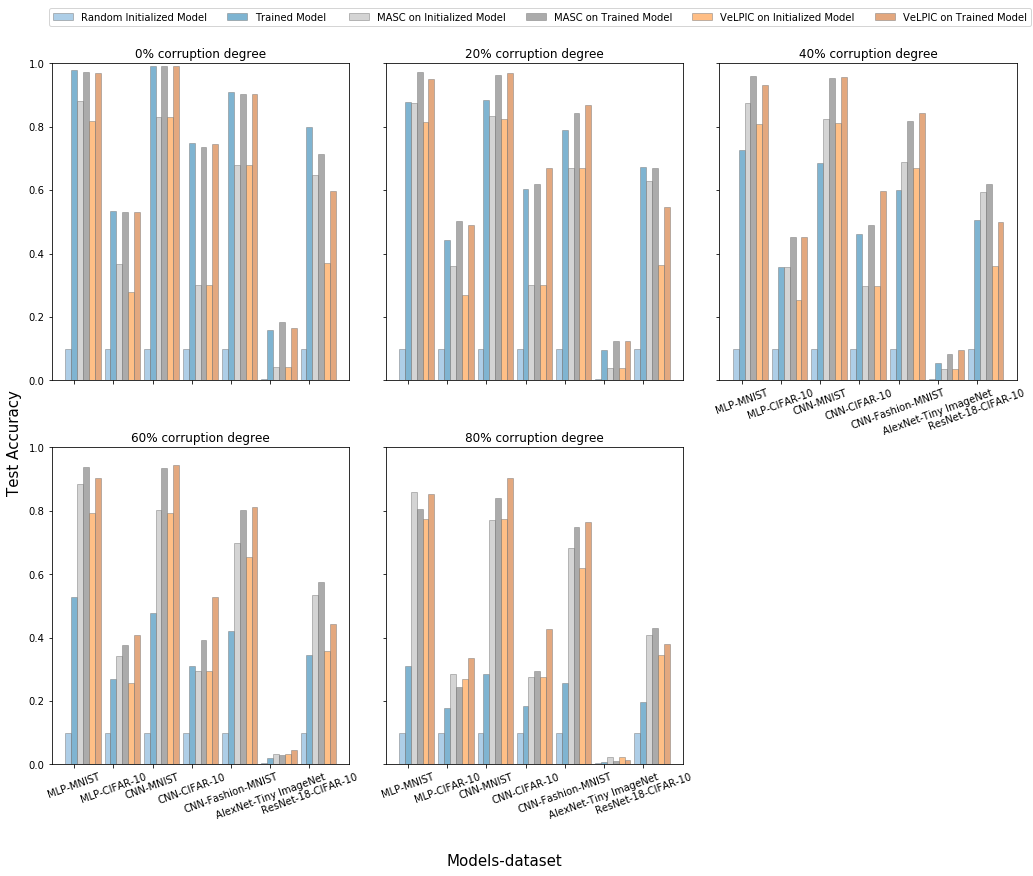

In [5]:
plo = plot()
resfoldername='TMLR_PAPER_PLOTS2'
plo.bar_models_random(resfoldername)